# Recursion

In [ ]:
When propblem does not have any overlapping sub-problem, then we can not use DP

# template
def subset(A, i):
    - order/ iterate over some list in a sequence
    - Think of possible cases.
        1. take = subset(A, fun(i))
        2. not_take = subset(A, fun(i))
    - maintain some auxilary info


def generate_subsets(arr, subset=[], index=0):
    """ For each 
    """
    if index == len(arr):
        print(subset)
        return

    # Include the current element
    include =  generate_subsets(arr, subset + [arr[index]], index + 1)

    # Exclude the current element
    exclude = generate_subsets(arr, subset, index + 1)    

# Example usage
arr = [1, 2, 3]
generate_subsets(arr)



# [1,2,3] there are 3 elements each can be included/ excluded, so 2^n possible answers.
# Total no. of nodes in tree: 2^(n+1) -1

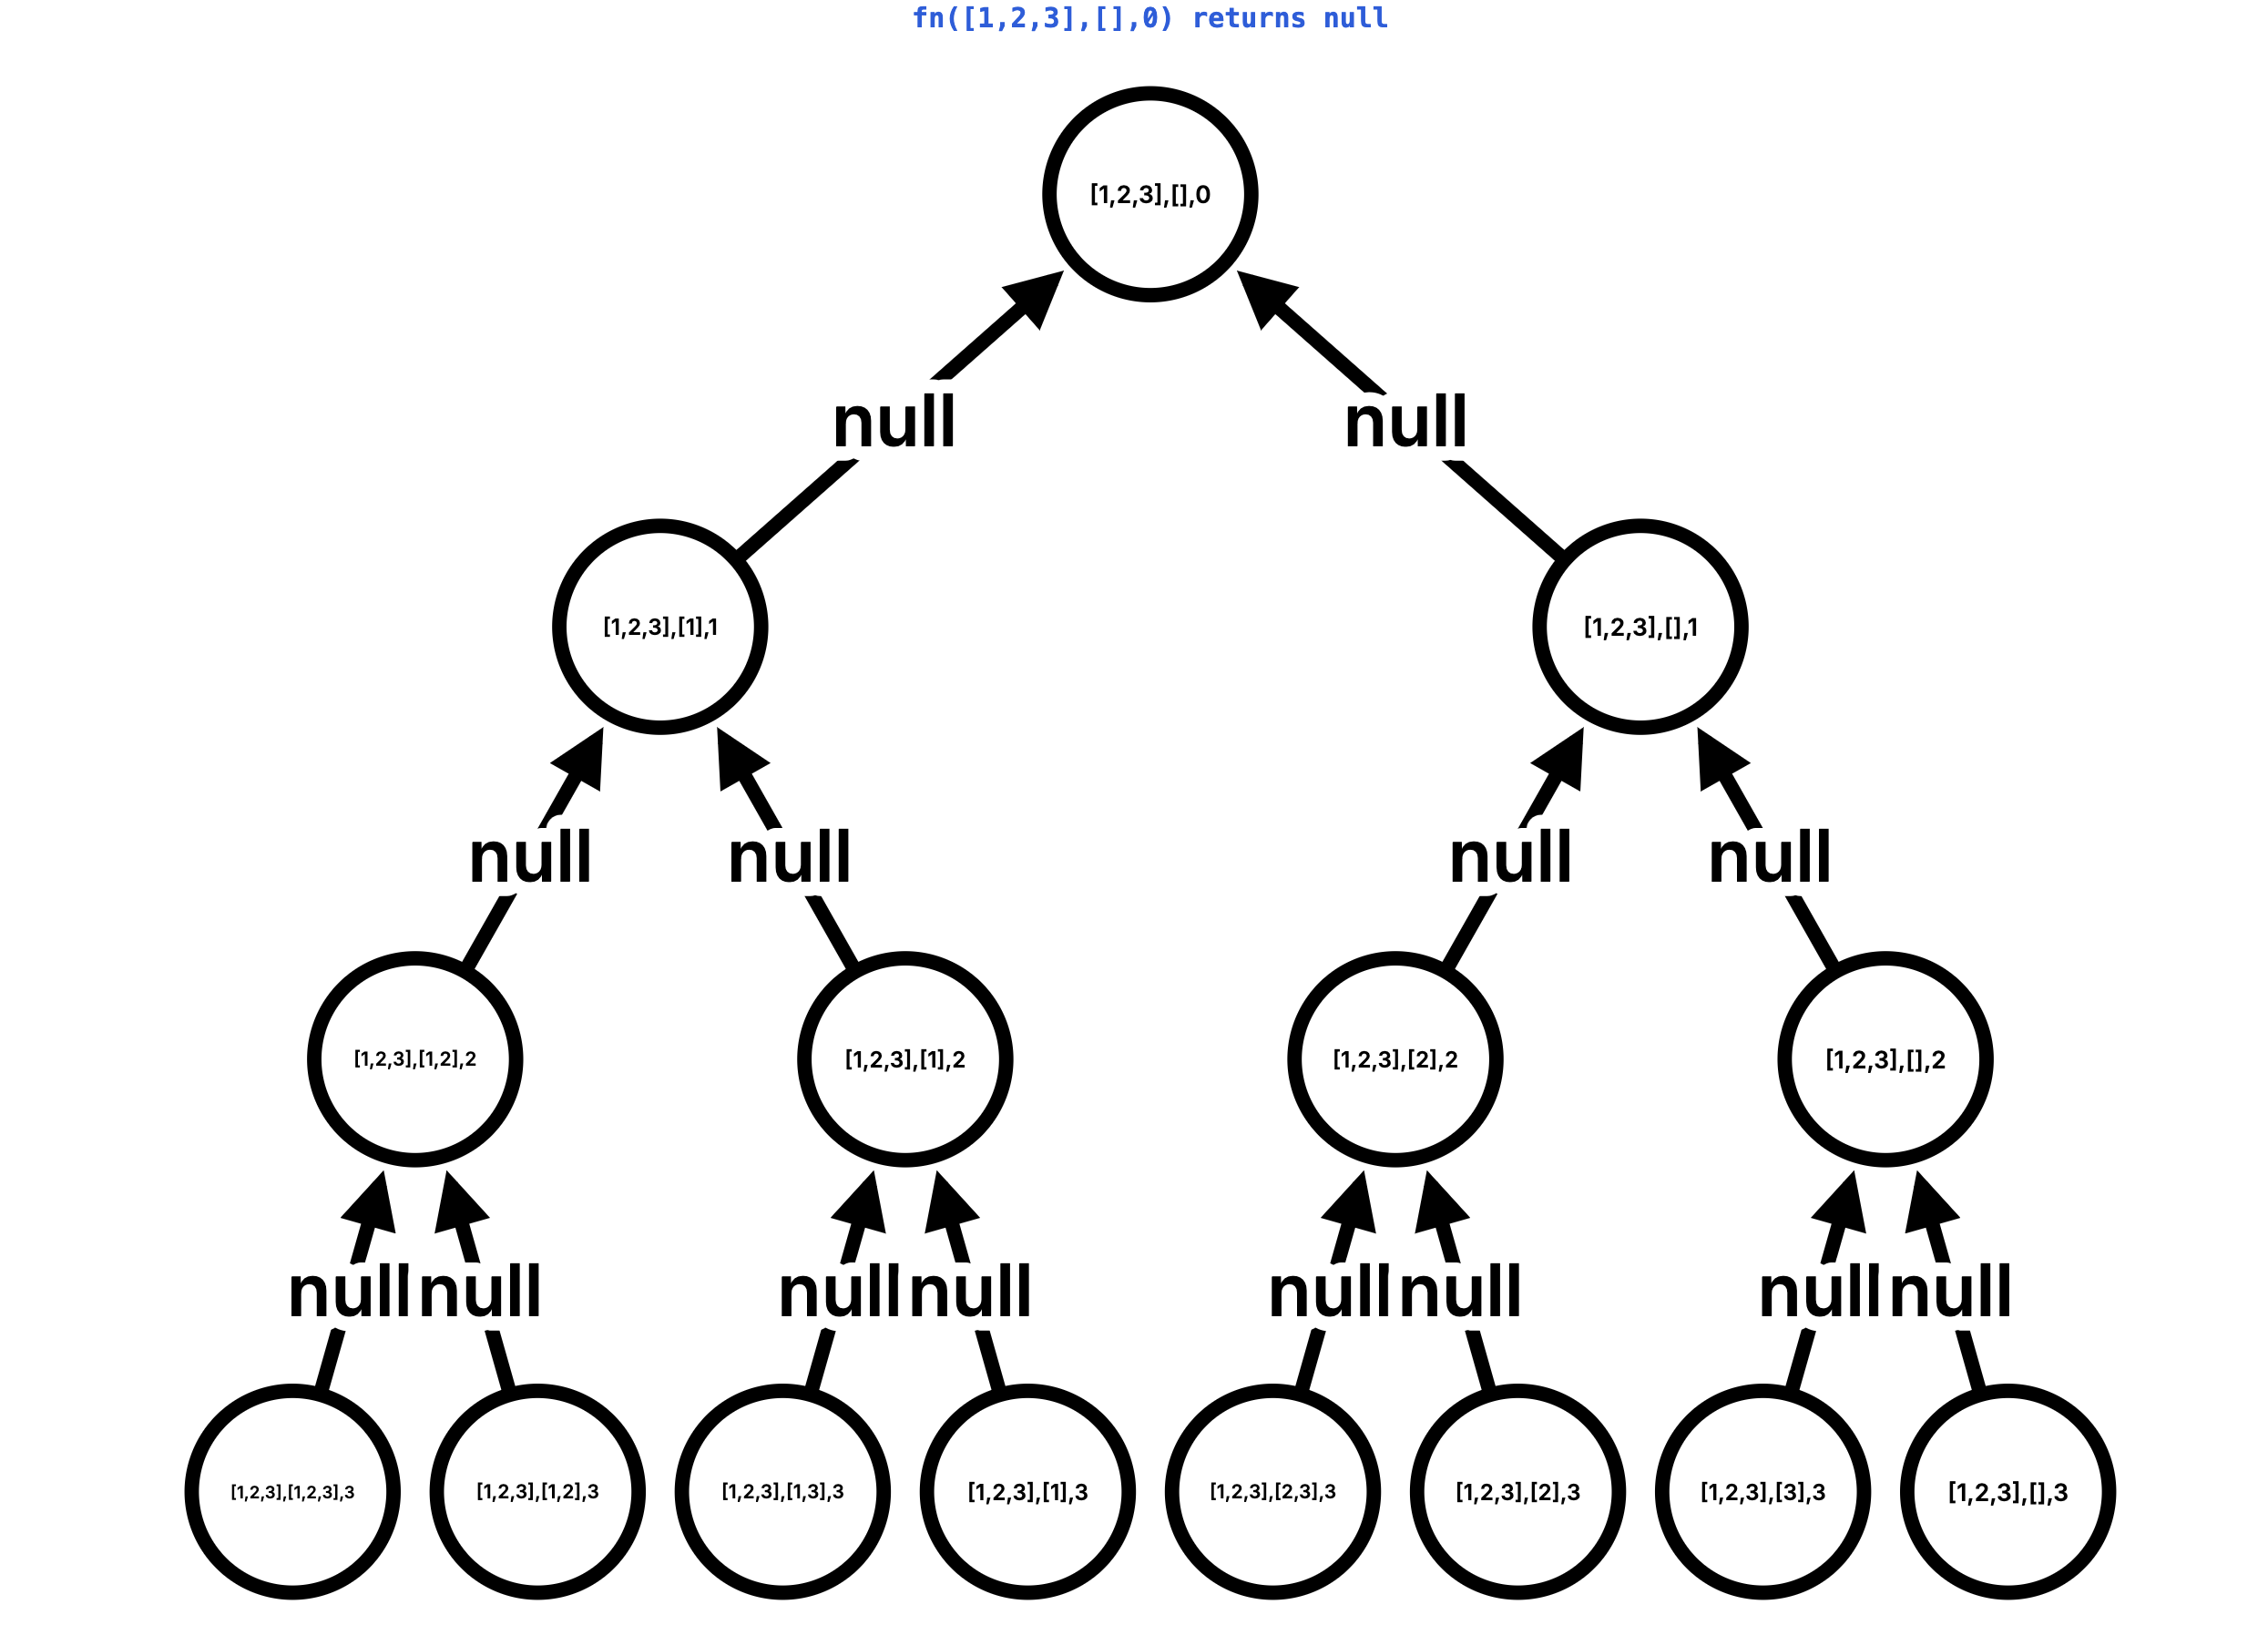

In [3]:
# Print numbers in lexographical order
- Perform initial sort on given array
- Print elements only when we move left in tree, instead of printing leaf nodes.

def generate_subsets(arr, subset=[], index=0, is_left_move= False):
    if (is_left_move):
        print(subset)
        
    if index == len(arr):
        #print(subset)
        return

    # Include the current element
    include =  generate_subsets(arr, subset + [arr[index]], index + 1, True)

    # Exclude the current element
    exclude = generate_subsets(arr, subset, index + 1, False)    

# Example usage
arr = [1, 2, 3]
generate_subsets(arr)

[1]
[1, 2]
[1, 2, 3]
[1, 3]
[2]
[2, 3]
[3]


In [ ]:
# Recursion call
take =   find_subsets(arr, k, subset + [arr[index]], index + 1, current_sum + arr[index])
    index + 1: Next, we need to check for index + 1 remaining elements
    current_sum + arr[index]: We have already decided to include this element.


# Print all the sub-sets having sum equal to k
def find_subsets(arr, k, subset=[], index=0, current_sum=0):
    """
    TC:
    •	O(2ⁿ) recursive calls (since every element has two choices)
	•	At each leaf, sum check is done in O(1) (because we are maintaining current_sum)
	•	Printing subset will take O(n) only if sum condition is met
    """
    if index == len(arr):
        if current_sum == k:
            print(subset)
        return

    # Include current element
    find_subsets(arr, k, subset + [arr[index]], index + 1, current_sum + arr[index])
     #.                                        We need to check of (index+1).  
    # Exclude current element
    find_subsets(arr, k, subset, index + 1, current_sum)


# Backtracking solution, it can be done with DP as well.
def count_subsets(arr, k, index=0, current_sum=0):
    """ TC: 2^n 
      - Printing each subset is not required.
    """
    if index == len(arr):
        return 1 if current_sum == k else 0

    # Include current element
    count_incl = count_subsets(arr, k, index + 1, current_sum + arr[index])

    # Exclude current element
    count_excl = count_subsets(arr, k, index + 1, current_sum)

    return count_incl + count_excl

# Example
arr = [1, 2, 3, 4]
k = 5
result = count_subsets(arr, k)
print(f"Total subsets with sum {k}: {result}")

# DP vs Backtracking

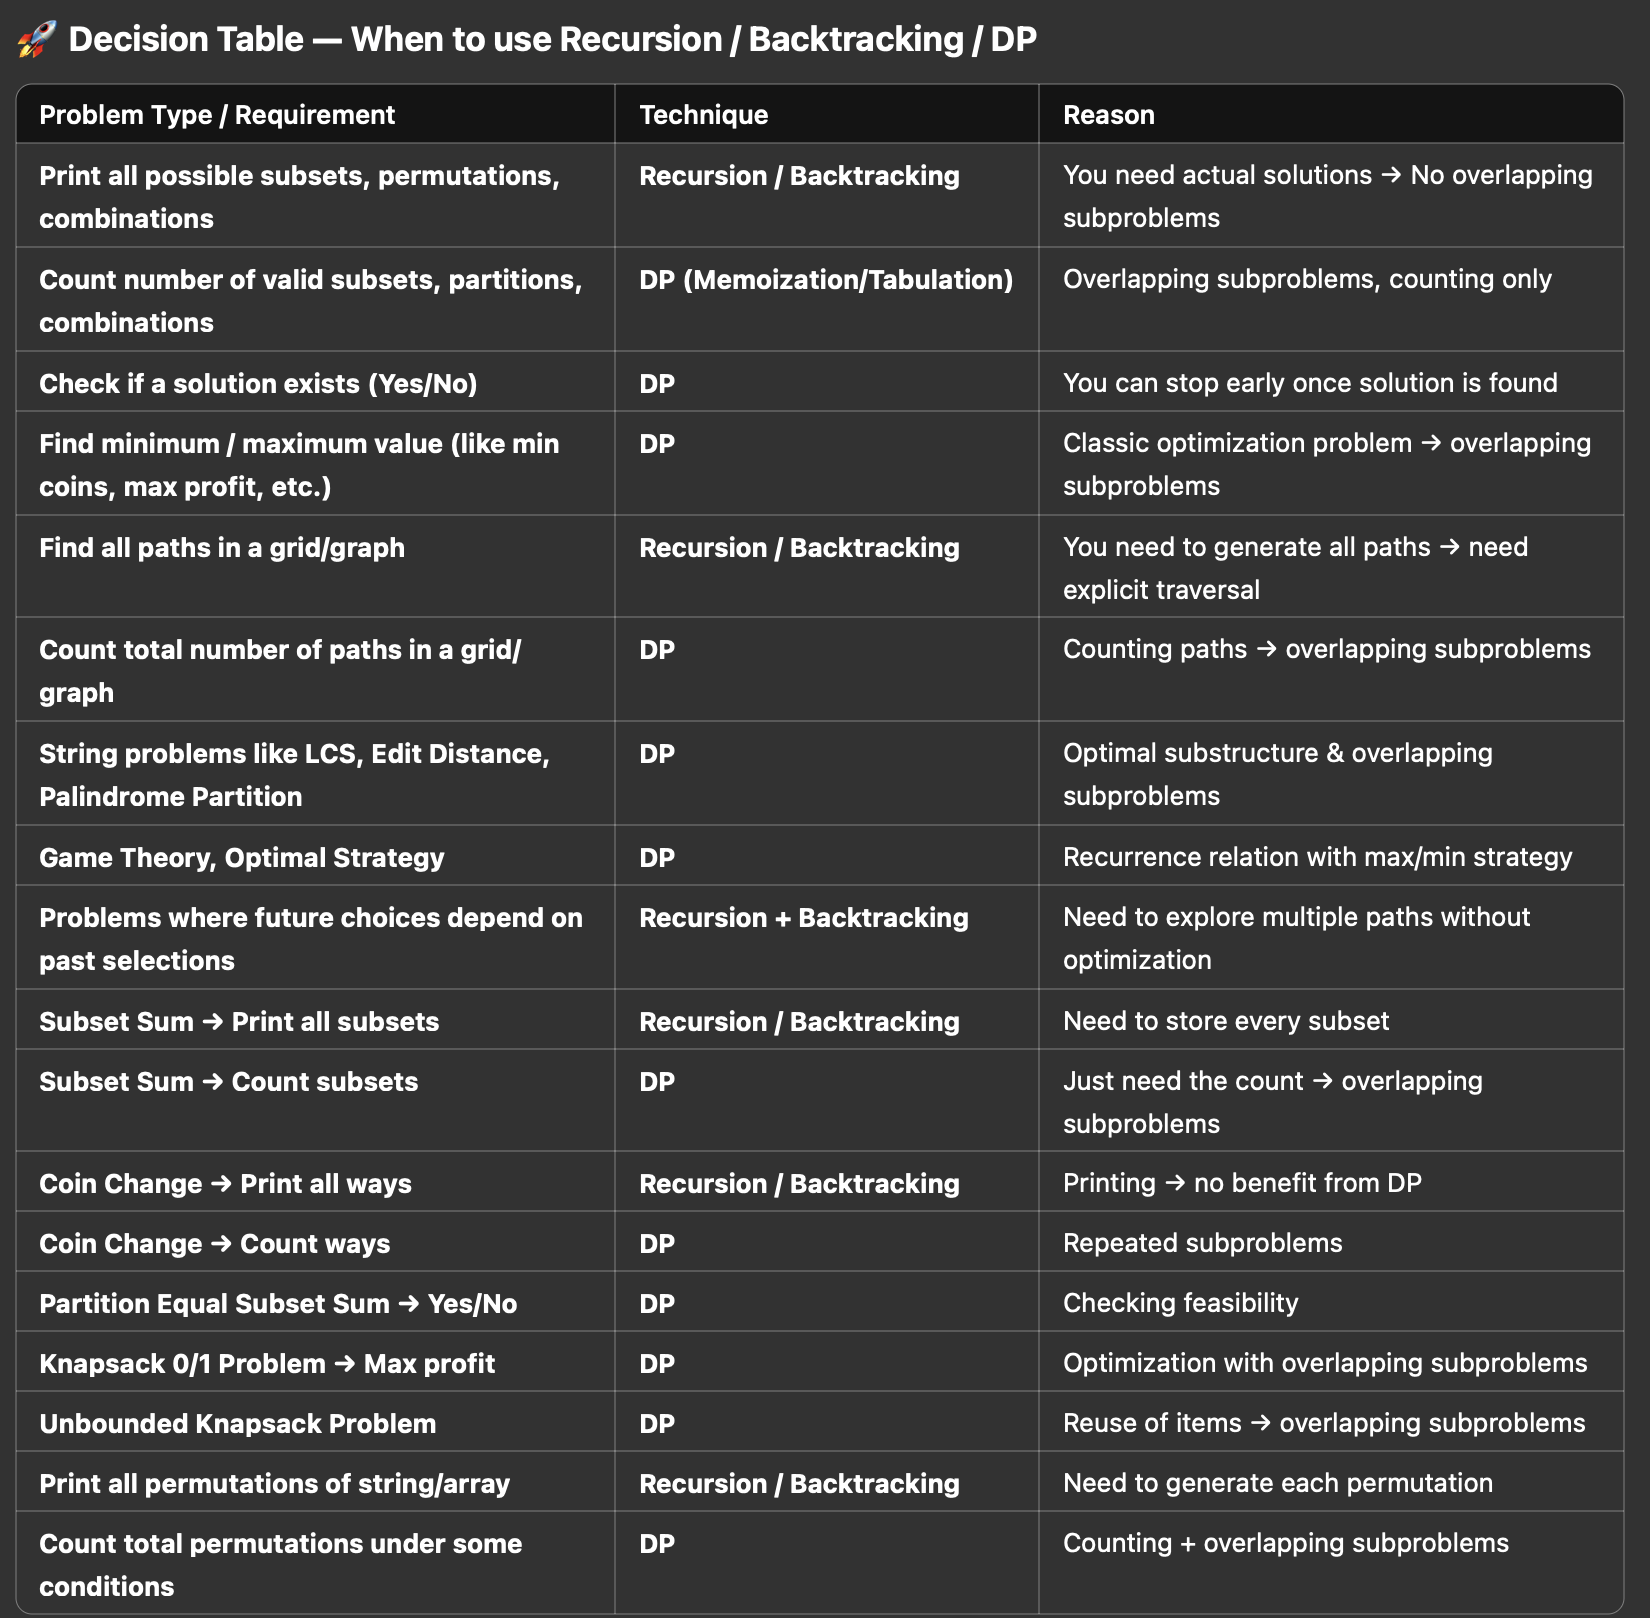

In [ ]:
# Problems
1. You need to count number of solutions - Backtracking
2. You need to check feasibility (Yes/No) - DP
3. You need to count number of solutions - DP
4. You need to minimize/maximize something (like min coins) - DP




In [ ]:
Whenever the problem says:
	•	Print/Generate all possible arrangements, orders, or subsets
and
	•	No constraints of sum, count, or optimization (only enumeration)
then, Backtracking + Swapping

# Print all possible permutation of a string "ABC"
Input: "abc"
Output:
abc
acb
bac
bca
cab
cba

def permute(s, l, r):
    """ TC: N * N!
        SC: N
    """
    if l == r:
        print(''.join(s))
    else:
        for i in range(l, r + 1):
            # Swap current index with l
            s[l], s[i] = s[i], s[l]
            # Recurse
            permute(s, l + 1, r)
            # Backtrack
            s[l], s[i] = s[i], s[l]

# Example
str_ = "abc"
permute(list(str_), 0, len(str_) - 1)

In [ ]:
# Explaination
permute(['a', 'b', 'c'], l = 0)
	•	Level 0 → When l = 0 → You are deciding which character will come at index 0. At 0th position, [0, 1,2] these characters will come
	•	Level 1 → When l = 1 → You are deciding which character will come at index 1. At 1st postion, [1, 2] these characters will come
	•	Level 2 → When l = 2 → You are deciding which character will come at index 2. At 2nd postion [2] these characters will come

          [a, b, c]    ← l = 0
         /    |    \
    [a, b, c][b, a, c][c, b, a] ← l = 1
     / \         / \         / \
abc  acb    bac  bca    cba  cab ← l = 2

Level 0 → N choices
Level 1 → N-1 choices
Level 2 → N-2 choices
…
Total number of permutations = N!

In [ ]:
# Print kth permutation of a string
n=4, "ABCD", and print k=16th permutation

Total permutations = 24, (4*3*2*1)


1. At 0th index, fix 0th index character. - [0-5], total 6 permutations
   0 + [(1, 2, 3)]
2. At 0th index, fix 1st index character. - [6-11], total 6 permutations
   1 + [(0, 2, 3)]
3. At 0th index, fix 2nd index character. - [12-17], total 6 permutations
   2 + [(1, 0, 3)]
4. At 0th index, fix 3rd index character. - [18-23], total 6 permutations
   3 + [(1, 2, 0)]

Here, we will form the answer string by adding character by character.

k=16 is asked, means it will fall in [12-17] range. which also means our first charcter will be 2nd index character
Answer: "C..."
Now the remaining set is, [1, 0, 3  ]



In [5]:
import math

def kth_permutation(s, k):
    s = sorted(s)  # Ensure lexicographical order
    n = len(s)
    k -= 1  # zero-based indexing
    result = []

    while n > 0:
        fact = math.factorial(n - 1)
        print(k, fact)
        index = k // fact
        result.append(s[index])
        s.pop(index)
        k = k % fact
        n -= 1

    return ''.join(result)

# Example Usage
s = "ABC"
k = 4
print(f"{k}th permutation of '{s}' is:", kth_permutation(s, k))

3 2
1 1
0 1
4th permutation of 'ABC' is: BCA


In [6]:
	•	Possible characters → 'A', 'B', 'C'
	•	Each character will have (N-1)! = 2! = 2 permutations.
	•	So:
	•	'A' → permutations from 1 to 2
	•	'B' → permutations from 3 to 4
	•	'C' → permutations from 5 to 6
    

6

In [ ]:
# Print all possible combinations of paranthesis

def generate_parentheses(n):
    """TC: 2^n
    """
    def backtrack(open_count, close_count, current):
        if len(current) == 2 * n:
            print(current)
            return
        if open_count < n:
            backtrack(open_count + 1, close_count, current + '(')
        if close_count < open_count:
            backtrack(open_count, close_count + 1, current + ')')

    backtrack(0, 0, "")

# Example usage
n = 3
generate_parentheses(n)

In [7]:
def letterCombinations(digits):
    if not digits:
        return []
    
    mapping = {
        '2': 'abc', '3': 'def', '4': 'ghi',
        '5': 'jkl', '6': 'mno', '7': 'pqrs',
        '8': 'tuv', '9': 'wxyz'
    }
    result = []
    
    def backtrack(index, path):
        if index == len(digits):
            result.append(path)
            return
        for char in mapping[digits[index]]:
            backtrack(index + 1, path + char)
    
    backtrack(0, "")
    return result

# Example
print(letterCombinations("23"))

['ad', 'ae', 'af', 'bd', 'be', 'bf', 'cd', 'ce', 'cf']
